FEATURE ENGINEERING & SELECTION (OPTIMIZED)

Dataset: 70,000 rows × 53 columns

ADVANCED FEATURE ENGINEERING
✓ Created 5 interaction features
✓ Created 4 polynomial features
✓ Created 6 ratio features
✓ Created 4 binning features
✓ Created 6 boolean features
✓ Created 1 time-based feature
✓ Created 8 service combination features
✓ Created 3 customer value features

✓ Current dataset shape: (70000, 90)

ENCODING CATEGORICAL FEATURES
✓ Found 18 categorical columns
✓ Label encoded 18 columns
✓ One-hot encoded 4 columns
✓ Final dataset shape: (70000, 120)

PREPARING DATA FOR FEATURE SELECTION
✓ Features: 103
✓ Target: 70000
✓ Churn rate: 41.74%
✓ Encoded 5 categorical columns
✓ Features scaled using StandardScaler

UNIVARIATE FEATURE SELECTION

Top 20 Features by ANOVA F-Score:
                   Feature      F_Score        P_Value
29               RFM_Score  1188.938308  2.296424e-258
15       SatisfactionIndex  1179.597044  2.277278e-256
7        SatisfactionScore  1011.737519  1.899627e

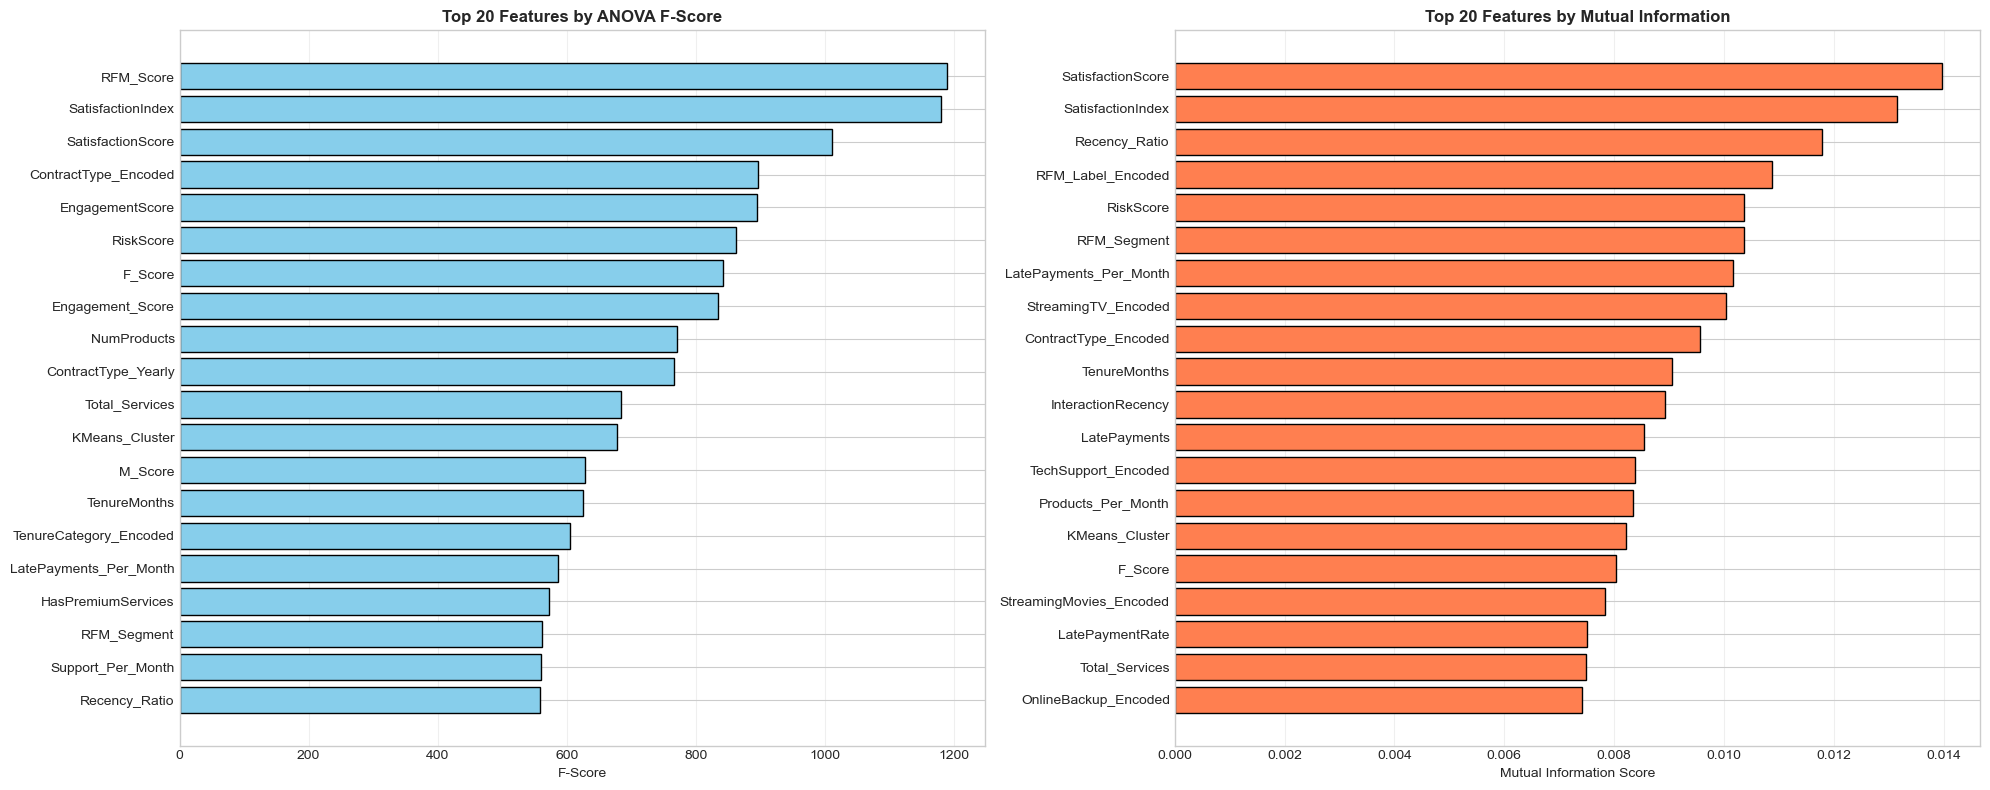


TREE-BASED FEATURE IMPORTANCE

Top 20 Features by Random Forest Importance:
                     Feature  Importance
15         SatisfactionIndex    0.062913
7          SatisfactionScore    0.055247
46             Recency_Ratio    0.040546
68          Engagement_Score    0.037897
71      ContractType_Encoded    0.037342
14                 RiskScore    0.034530
93       ContractType_Yearly    0.033958
13           EngagementScore    0.030470
37      TenureMonths_Squared    0.024646
33                Age_Tenure    0.024233
32     Tenure_MonthlyCharges    0.021444
1               TenureMonths    0.021262
24          SupportIntensity    0.019648
2   DaysSinceLastInteraction    0.017942
18        InteractionRecency    0.017511
43         Support_Per_Month    0.016341
8          AvgMonthlyUsageGB    0.016239
34      Usage_MonthlyCharges    0.016080
3             MonthlyCharges    0.015707
40      TotalCharges_Squared    0.015603

Top 20 Features by Gradient Boosting Importance:
            

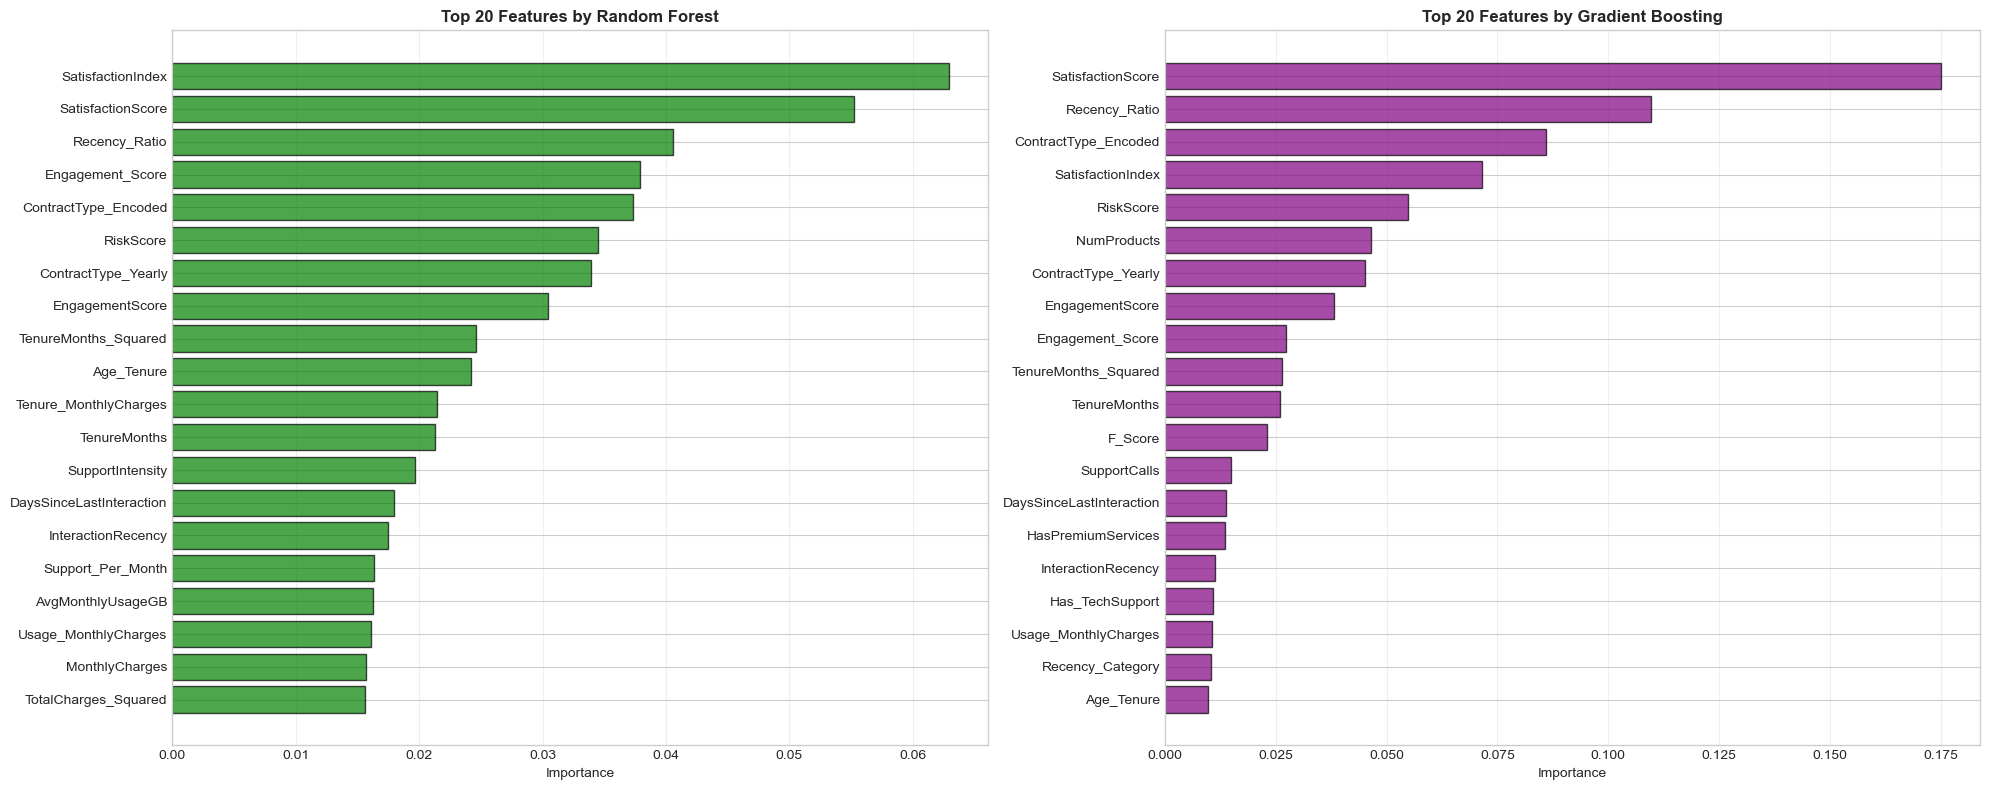


RECURSIVE FEATURE ELIMINATION (OPTIMIZED)
Creating stratified sample for RFE (10,000 samples)...

RFE Results (Top 30 Features):
                    Feature  Selected  Ranking
0                       Age      True        1
57         Recency_Category      True        1
54           Is_LatePayment      True        1
48             Tenure_Group      True        1
24         SupportIntensity      True        1
25          LatePaymentRate      True        1
43        Support_Per_Month      True        1
38   MonthlyCharges_Squared      True        1
27                  F_Score      True        1
29                RFM_Score      True        1
41        Charges_Per_Month      True        1
40     TotalCharges_Squared      True        1
32    Tenure_MonthlyCharges      True        1
39              Age_Squared      True        1
34     Usage_MonthlyCharges      True        1
42         Usage_Per_Dollar      True        1
17       PaymentReliability      True        1
60          Has_TechSupp

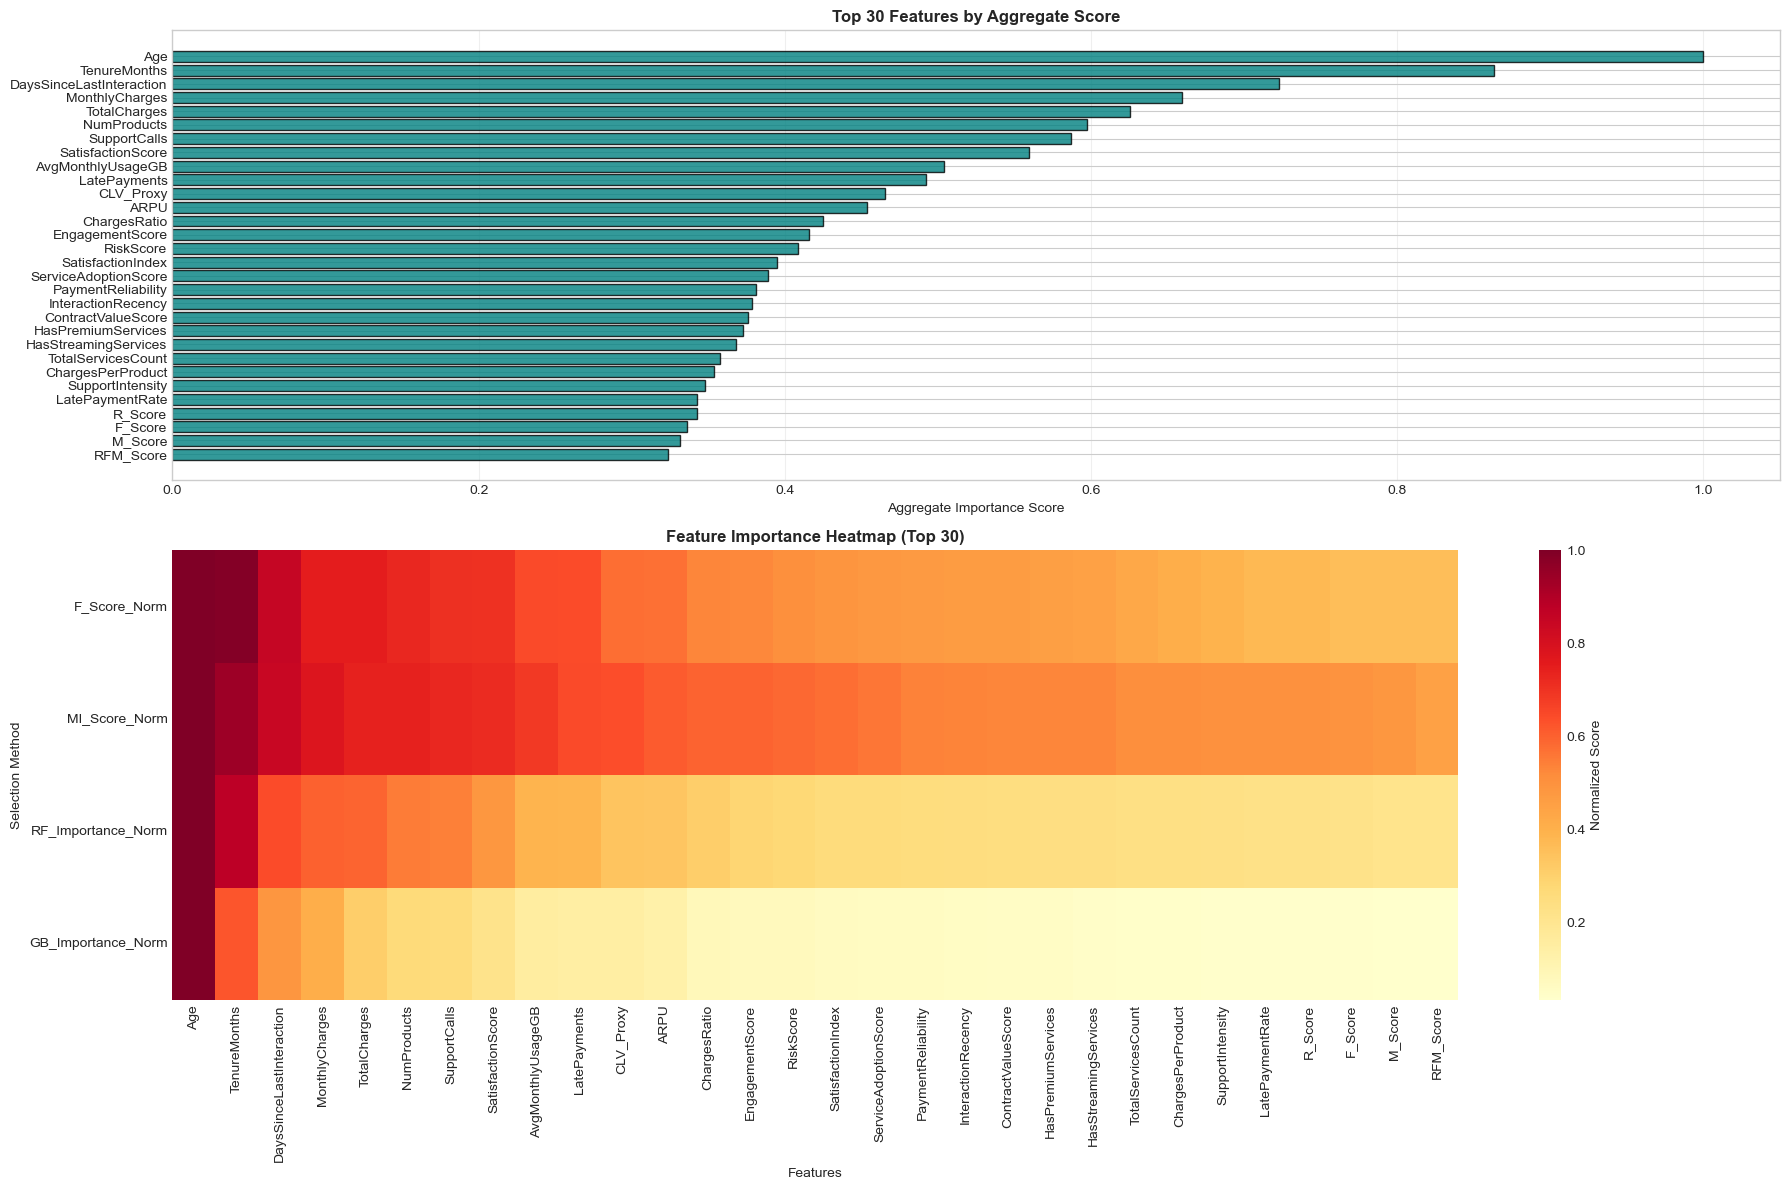


SELECTING FINAL FEATURES
✓ Selected 50 features for modeling

✓ Final feature set shape: (70000, 50)
✓ Target shape: (70000,)

SAVING PROCESSED DATA
✓ Saved: customer_churn_engineered.csv
✓ Saved: selected_features.csv
✓ Saved: feature_importance_scores.csv
✓ Saved: customer_churn_final.csv

FEATURE ENGINEERING & SELECTION COMPLETED

Summary:
  • Original features: 20
  • Engineered features: 88
  • Total features after encoding: 103
  • Selected features for modeling: 50
  • Churn rate: 41.74%


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# NOTEBOOK 08: FEATURE ENGINEERING & SELECTION (OPTIMIZED)
# Purpose: Create advanced features and select the most important ones for modeling
# ═══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)

# ═══════════════════════════════════════════════════════════════════════════════
# 1. LOAD DATA
# ═══════════════════════════════════════════════════════════════════════════════

df = pd.read_csv('../data/processed/customer_churn_segmented.csv')

print("="*80)
print("FEATURE ENGINEERING & SELECTION (OPTIMIZED)")
print("="*80)
print(f"\nDataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

# ═══════════════════════════════════════════════════════════════════════════════
# 2. ADVANCED FEATURE ENGINEERING
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("ADVANCED FEATURE ENGINEERING")
print("="*80)

# 2.1 Interaction Features
df['Tenure_MonthlyCharges'] = df['TenureMonths'] * df['MonthlyCharges']
df['Age_Tenure'] = df['Age'] * df['TenureMonths']
df['Usage_MonthlyCharges'] = df['AvgMonthlyUsageGB'] * df['MonthlyCharges']
df['LatePayments_MonthlyCharges'] = df['LatePayments'] * df['MonthlyCharges']
df['SupportCalls_Tenure'] = df['SupportCalls'] * df['TenureMonths']
print("✓ Created 5 interaction features")

# 2.2 Polynomial Features
df['TenureMonths_Squared'] = df['TenureMonths'] ** 2
df['MonthlyCharges_Squared'] = df['MonthlyCharges'] ** 2
df['Age_Squared'] = df['Age'] ** 2
df['TotalCharges_Squared'] = df['TotalCharges'] ** 2
print("✓ Created 4 polynomial features")

# 2.3 Ratio Features
df['Charges_Per_Month'] = df['TotalCharges'] / (df['TenureMonths'] + 1)
df['Usage_Per_Dollar'] = df['AvgMonthlyUsageGB'] / (df['MonthlyCharges'] + 1)
df['Support_Per_Month'] = df['SupportCalls'] / (df['TenureMonths'] + 1)
df['Products_Per_Month'] = df['NumProducts'] / (df['TenureMonths'] + 1)
df['LatePayments_Per_Month'] = df['LatePayments'] / (df['TenureMonths'] + 1)
df['Recency_Ratio'] = df['DaysSinceLastInteraction'] / (df['TenureMonths'] * 30 + 1)
print("✓ Created 6 ratio features")

# 2.4 Binning Features
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 30, 45, 60, 100], 
                          labels=['Young', 'Middle', 'Senior', 'Elderly'])
df['Tenure_Group'] = pd.cut(df['TenureMonths'], bins=[0, 12, 24, 48, 100], 
                             labels=['New', 'Regular', 'Loyal', 'VeryLoyal'])
df['Revenue_Group'] = pd.qcut(df['TotalCharges'], q=4, 
                               labels=['Low', 'Medium', 'High', 'VeryHigh'], duplicates='drop')
df['Usage_Group'] = pd.qcut(df['AvgMonthlyUsageGB'], q=4,
                             labels=['LowUsage', 'MediumUsage', 'HighUsage', 'VeryHighUsage'], duplicates='drop')
print("✓ Created 4 binning features")

# 2.5 Boolean Features
df['Is_HighCharges'] = (df['MonthlyCharges'] > df['MonthlyCharges'].quantile(0.75)).astype(int)
df['Is_LowSatisfaction'] = (df['SatisfactionScore'] <= 2).astype(int)
df['Is_HighSupport'] = (df['SupportCalls'] > df['SupportCalls'].quantile(0.75)).astype(int)
df['Is_LatePayment'] = (df['LatePayments'] > 0).astype(int)
df['Is_RecentInteraction'] = (df['DaysSinceLastInteraction'] <= 7).astype(int)
df['Is_LongTenure'] = (df['TenureMonths'] >= 48).astype(int)
print("✓ Created 6 boolean features")

# 2.6 Time-based Features
df['Recency_Category'] = pd.cut(df['DaysSinceLastInteraction'], 
                                 bins=[0, 7, 30, 90, 365], 
                                 labels=['VeryRecent', 'Recent', 'Moderate', 'Old'])
print("✓ Created 1 time-based feature")

# 2.7 Service Combination Features
service_cols = ['OnlineSecurity', 'OnlineBackup', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in service_cols:
    df[f'Has_{col}'] = df[col].apply(lambda x: 1 if x == 'Yes' else 0)

df['Total_Services'] = (df['Has_OnlineSecurity'] + df['Has_OnlineBackup'] + 
                        df['Has_TechSupport'] + df['Has_StreamingTV'] + df['Has_StreamingMovies'])
df['Has_Security_Bundle'] = ((df['Has_OnlineSecurity'] == 1) & (df['Has_OnlineBackup'] == 1)).astype(int)
df['Has_Entertainment_Bundle'] = ((df['Has_StreamingTV'] == 1) & (df['Has_StreamingMovies'] == 1)).astype(int)
print("✓ Created 8 service combination features")

# 2.8 Customer Value Features
df['Customer_Lifetime_Value'] = df['TotalCharges'] + (df['MonthlyCharges'] * 12)
df['Revenue_Per_Product'] = df['TotalCharges'] / (df['NumProducts'] + 1)
df['Engagement_Score'] = (df['NumProducts'] * 10) + (df['AvgMonthlyUsageGB'] / 10) - (df['DaysSinceLastInteraction'] / 10)
print("✓ Created 3 customer value features")

print(f"\n✓ Current dataset shape: {df.shape}")

# ═══════════════════════════════════════════════════════════════════════════════
# 3. ENCODE CATEGORICAL FEATURES
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("ENCODING CATEGORICAL FEATURES")
print("="*80)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ['CustomerID', 'SignupDate']]
print(f"✓ Found {len(categorical_cols)} categorical columns")

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[f'{col}_Encoded'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
print(f"✓ Label encoded {len(categorical_cols)} columns")

nominal_cols = ['PaymentMethod', 'InternetService', 'ContractType', 'City']
df_encoded = pd.get_dummies(df, columns=nominal_cols, prefix=nominal_cols, drop_first=True)
print(f"✓ One-hot encoded {len(nominal_cols)} columns")
print(f"✓ Final dataset shape: {df_encoded.shape}")

# ═══════════════════════════════════════════════════════════════════════════════
# 4. PREPARE DATA FOR FEATURE SELECTION
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("PREPARING DATA FOR FEATURE SELECTION")
print("="*80)

cols_to_drop = ['CustomerID', 'SignupDate', 'Churn'] + categorical_cols
X = df_encoded.drop(columns=cols_to_drop, errors='ignore')
y = df_encoded['Churn']

print(f"✓ Features: {X.shape[1]}")
print(f"✓ Target: {y.shape[0]}")
print(f"✓ Churn rate: {y.mean():.2%}")

scaler = StandardScaler()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

if categorical_cols:
    le = LabelEncoder()
    for col in categorical_cols:
        X[col] = le.fit_transform(X[col].astype(str))
    print(f"✓ Encoded {len(categorical_cols)} categorical columns")

X.fillna(0, inplace=True) 

X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print(f"✓ Features scaled using StandardScaler")

# ═══════════════════════════════════════════════════════════════════════════════
# 5. UNIVARIATE FEATURE SELECTION
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("UNIVARIATE FEATURE SELECTION")
print("="*80)

# 5.1 ANOVA F-test
selector_f = SelectKBest(score_func=f_classif, k='all')
selector_f.fit(X_scaled, y)

f_scores = pd.DataFrame({
    'Feature': X.columns,
    'F_Score': selector_f.scores_,
    'P_Value': selector_f.pvalues_
}).sort_values('F_Score', ascending=False)

print("\nTop 20 Features by ANOVA F-Score:")
print(f_scores.head(20))

# 5.2 Mutual Information
selector_mi = SelectKBest(score_func=mutual_info_classif, k='all')
selector_mi.fit(X_scaled, y)

mi_scores = pd.DataFrame({
    'Feature': X.columns,
    'MI_Score': selector_mi.scores_
}).sort_values('MI_Score', ascending=False)

print("\nTop 20 Features by Mutual Information:")
print(mi_scores.head(20))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

top_f = f_scores.head(20)
axes[0].barh(range(len(top_f)), top_f['F_Score'], color='skyblue', edgecolor='black')
axes[0].set_yticks(range(len(top_f)))
axes[0].set_yticklabels(top_f['Feature'])
axes[0].set_xlabel('F-Score')
axes[0].set_title('Top 20 Features by ANOVA F-Score', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

top_mi = mi_scores.head(20)
axes[1].barh(range(len(top_mi)), top_mi['MI_Score'], color='coral', edgecolor='black')
axes[1].set_yticks(range(len(top_mi)))
axes[1].set_yticklabels(top_mi['Feature'])
axes[1].set_xlabel('Mutual Information Score')
axes[1].set_title('Top 20 Features by Mutual Information', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/results/08_univariate_selection.png', dpi=300, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 6. TREE-BASED FEATURE IMPORTANCE (OPTIMIZED)
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("TREE-BASED FEATURE IMPORTANCE")
print("="*80)

# 6.1 Random Forest
rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_scaled, y)

rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 20 Features by Random Forest Importance:")
print(rf_importance.head(20))

# 6.2 Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=50, max_depth=5, random_state=42)
gb.fit(X_scaled, y)

gb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 20 Features by Gradient Boosting Importance:")
print(gb_importance.head(20))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

top_rf = rf_importance.head(20)
axes[0].barh(range(len(top_rf)), top_rf['Importance'], color='green', edgecolor='black', alpha=0.7)
axes[0].set_yticks(range(len(top_rf)))
axes[0].set_yticklabels(top_rf['Feature'])
axes[0].set_xlabel('Importance')
axes[0].set_title('Top 20 Features by Random Forest', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

top_gb = gb_importance.head(20)
axes[1].barh(range(len(top_gb)), top_gb['Importance'], color='purple', edgecolor='black', alpha=0.7)
axes[1].set_yticks(range(len(top_gb)))
axes[1].set_yticklabels(top_gb['Feature'])
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 20 Features by Gradient Boosting', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/results/08_tree_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 7. RECURSIVE FEATURE ELIMINATION (OPTIMIZED)
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("RECURSIVE FEATURE ELIMINATION (OPTIMIZED)")
print("="*80)

print("Creating stratified sample for RFE (10,000 samples)...")
X_sample, _, y_sample, _ = train_test_split(
    X_scaled, y, train_size=10000, stratify=y, random_state=42
)

lr = LogisticRegression(max_iter=500, random_state=42, solver='saga', n_jobs=-1)
rfe = RFE(estimator=lr, n_features_to_select=30, step=10)
rfe.fit(X_sample, y_sample)

rfe_features = pd.DataFrame({
    'Feature': X.columns,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
}).sort_values('Ranking')

print("\nRFE Results (Top 30 Features):")
print(rfe_features[rfe_features['Selected'] == True])

# ═══════════════════════════════════════════════════════════════════════════════
# 8. FEATURE IMPORTANCE AGGREGATION
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("FEATURE IMPORTANCE AGGREGATION")
print("="*80)

importance_df = pd.DataFrame({'Feature': X.columns})

importance_df['F_Score_Norm'] = (f_scores.set_index('Feature')['F_Score'] / f_scores['F_Score'].max()).values
importance_df['MI_Score_Norm'] = (mi_scores.set_index('Feature')['MI_Score'] / mi_scores['MI_Score'].max()).values
importance_df['RF_Importance_Norm'] = (rf_importance.set_index('Feature')['Importance'] / rf_importance['Importance'].max()).values
importance_df['GB_Importance_Norm'] = (gb_importance.set_index('Feature')['Importance'] / gb_importance['Importance'].max()).values
importance_df['RFE_Selected'] = rfe_features.set_index('Feature')['Selected'].astype(int).values

importance_df['Aggregate_Score'] = (
    importance_df['F_Score_Norm'] * 0.2 +
    importance_df['MI_Score_Norm'] * 0.2 +
    importance_df['RF_Importance_Norm'] * 0.25 +
    importance_df['GB_Importance_Norm'] * 0.25 +
    importance_df['RFE_Selected'] * 0.1
)

importance_df = importance_df.sort_values('Aggregate_Score', ascending=False)

print("\nTop 30 Features by Aggregate Score:")
print(importance_df.head(30))

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

top_30 = importance_df.head(30)
axes[0].barh(range(len(top_30)), top_30['Aggregate_Score'], color='teal', edgecolor='black', alpha=0.8)
axes[0].set_yticks(range(len(top_30)))
axes[0].set_yticklabels(top_30['Feature'])
axes[0].set_xlabel('Aggregate Importance Score')
axes[0].set_title('Top 30 Features by Aggregate Score', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

top_30_heatmap = top_30[['Feature', 'F_Score_Norm', 'MI_Score_Norm', 
                          'RF_Importance_Norm', 'GB_Importance_Norm']].set_index('Feature')
sns.heatmap(top_30_heatmap.T, annot=False, cmap='YlOrRd', ax=axes[1], 
            cbar_kws={'label': 'Normalized Score'})
axes[1].set_title('Feature Importance Heatmap (Top 30)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Features')
axes[1].set_ylabel('Selection Method')

plt.tight_layout()
plt.savefig('../data/results/08_aggregate_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 9. SELECT FINAL FEATURES
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("SELECTING FINAL FEATURES")
print("="*80)

top_features = importance_df.head(50)['Feature'].tolist()

print(f"✓ Selected {len(top_features)} features for modeling")

X_final = X[top_features]
y_final = y

print(f"\n✓ Final feature set shape: {X_final.shape}")
print(f"✓ Target shape: {y_final.shape}")

# ═══════════════════════════════════════════════════════════════════════════════
# 10. SAVE PROCESSED DATA
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("SAVING PROCESSED DATA")
print("="*80)

df_encoded.to_csv('../data/processed/customer_churn_engineered.csv', index=False)
print("✓ Saved: customer_churn_engineered.csv")

pd.DataFrame({'Feature': top_features}).to_csv('../data/processed/selected_features.csv', index=False)
print("✓ Saved: selected_features.csv")

importance_df.to_csv('../data/processed/feature_importance_scores.csv', index=False)
print("✓ Saved: feature_importance_scores.csv")

final_data = pd.concat([X_final, y_final], axis=1)
final_data.to_csv('../data/processed/customer_churn_final.csv', index=False)
print("✓ Saved: customer_churn_final.csv")

print("\n" + "="*80)
print("FEATURE ENGINEERING & SELECTION COMPLETED")
print("="*80)
print(f"\nSummary:")
print(f"  • Original features: {len(categorical_cols) + 15}")
print(f"  • Engineered features: {df.shape[1] - len(categorical_cols) - 15}")
print(f"  • Total features after encoding: {X.shape[1]}")
print(f"  • Selected features for modeling: {len(top_features)}")
print(f"  • Churn rate: {y.mean():.2%}")
